### Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import os
from scipy import stats
from scipy.stats import linregress

#### Data Loading & Date Parsing

In [3]:
df = pd.read_csv("../data/kenya.csv")
print(df.shape)
display(df.head())

(4108, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


Add Country column

In [4]:
df["Country"] = "Kenya"

viewing the top rows of the data after adding country column

In [5]:
display(df.head())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya


Viewing the bottom rows of the dataset

In [6]:
display(df.tail())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya
4107,2026,90,19.59,25.54,15.37,10.17,1.29,80.88,2.15,3.58,83.92,13.40,Kenya


In [7]:
# added Country column
print(df.shape)
print(df.columns.tolist())

(4108, 13)
['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country']


##### Convert YEAR and DOY to a single Datetime column

In [8]:
# 3. Convert YEAR and DOY to a single Datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# 4. Extract Month for seasonal analysis
df["Month"] = df["Date"].dt.month

# 5. Set Date as the index
df.set_index("Date", inplace=True)

# Final check of the data structure
print(df.shape)
print(f"Dataset columns: {df.columns.tolist()}")
df.head()

(4108, 14)
Dataset columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Month']


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-01,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,1
2015-01-02,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,1
2015-01-03,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,1
2015-01-04,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,1
2015-01-05,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,1


Drop redundant columns after changing to datetime

In [9]:
df.drop(columns=["YEAR", "DOY"], inplace=True)

# Final check to see the clean dataset
print("Redundant columns removed.")
df.head()

Redundant columns removed.


,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,
2015-01-01,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,1
2015-01-02,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,1
2015-01-03,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,1
2015-01-04,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,1
2015-01-05,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,1


In [10]:
print(df.index)

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-10',
               ...
               '2026-03-22', '2026-03-23', '2026-03-24', '2026-03-25',
               '2026-03-26', '2026-03-27', '2026-03-28', '2026-03-29',
               '2026-03-30', '2026-03-31'],
              dtype='datetime64[us]', name='Date', length=4108, freq=None)


In [11]:
display(df.loc['2015-01-01'])

T2M            19.56
T2M_MAX        28.99
T2M_MIN        12.09
T2M_RANGE       16.9
PRECTOTCORR      0.0
RH2M           45.32
WS2M            3.12
WS2M_MAX        4.76
PS             83.68
QV2M            6.88
Country        Kenya
Month              1
Name: 2015-01-01 00:00:00, dtype: object

### Summary Statistics & Missing-Value Report

In [12]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.DataFrame'>
DatetimeIndex: 4108 entries, 2015-01-01 to 2026-03-31
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   T2M          4108 non-null   float64
 1   T2M_MAX      4108 non-null   float64
 2   T2M_MIN      4108 non-null   float64
 3   T2M_RANGE    4108 non-null   float64
 4   PRECTOTCORR  4108 non-null   float64
 5   RH2M         4108 non-null   float64
 6   WS2M         4108 non-null   float64
 7   WS2M_MAX     4108 non-null   float64
 8   PS           4108 non-null   float64
 9   QV2M         4108 non-null   float64
 10  Country      4108 non-null   str    
 11  Month        4108 non-null   int32  
dtypes: float64(10), int32(1), str(1)
memory usage: 550.8 KB
None


A. Handling NASA Sentinel Values (-999) 

In [ ]:
# Create a count of how many -999 values exist in each column
sentinel_counts = (df == -999).sum()

# Filter to show only columns that actually have -999 values
sentinel_counts = sentinel_counts[sentinel_counts > 0]

print("--- NASA Sentinel Value (-999) Report ---")
if not sentinel_counts.empty:
    print(sentinel_counts)
else:
    print("No -999 values found in the dataset.")

df.replace(-999, np.nan, inplace=True)

--- NASA Sentinel Value (-999) Report ---
No -999 values found in the dataset.


,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,
2015-01-01,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,1
2015-01-02,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,1
2015-01-03,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,1
2015-01-04,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,1
2015-01-05,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,3
2026-03-28,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,3
2026-03-29,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,3


B. Duplicate Check

In [14]:
duplicates_count = df.duplicated().sum()

print(f"Total Duplicate Rows Found: {duplicates_count}")

# If duplicates exist, we drop them
if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates dropped successfully.")

Total Duplicate Rows Found: 0


C. Statistical Profiling
- Using df.describe() to get statistical summary of the numerical columns in a DataFrame

In [15]:
# Generate descriptive statistics for all numeric columns
print("summary statistics")
display(df.describe())

summary statistics


,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,6.423564
std,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,3.477046
min,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,1.000000
25%,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,3.000000
50%,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,6.000000
75%,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,9.000000
max,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,12.000000


D. Missing Value Analysis (Null Percentage)

In [16]:
null_counts = df.isna().sum()


total_rows = len(df)
null_percentages = (null_counts / total_rows) * 100

missing_report = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage (%)': null_percentages
})

# Filter for columns with any missing values
missing_report = missing_report[missing_report['Missing Values'] > 0]

print("Missing Value Report")
display(missing_report)

# Flagging columns with >5% missing data
high_null_cols = null_percentages[null_percentages > 5].index.tolist()
if high_null_cols:
    print(f"WARNING: The following columns have >5% missing data: {high_null_cols}")
else:
    print("All columns have less than 5% missing data. The dataset is healthy.")

Missing Value Report


,Missing Values,Percentage (%)


All columns have less than 5% missing data. The dataset is healthy.


#### Outlier Detection & Basic Cleaning

In [17]:
cols_to_check = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

In [18]:
z_scores= np.abs(stats.zscore(df[cols_to_check]))

In [19]:
outlier_mask = (z_scores > 3).any(axis=1)
print(f"\nRows flagged as outliers: {outlier_mask.sum()}")


Rows flagged as outliers: 121


In [20]:
# Preview flagged rows
display(df[outlier_mask].head())

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,
2015-01-15,21.24,31.17,12.59,18.58,0.00,28.42,3.27,4.78,83.61,4.78,Kenya,1
2015-01-16,22.95,32.70,14.62,18.08,0.00,29.64,2.30,3.41,83.54,5.58,Kenya,1
2015-01-17,23.00,32.29,15.79,16.50,0.00,29.43,2.71,3.91,83.55,5.68,Kenya,1
2015-01-18,23.38,32.42,13.97,18.45,0.16,32.67,1.43,3.07,83.62,6.53,Kenya,1
2015-02-15,22.14,27.92,18.11,9.81,23.09,61.69,0.97,1.97,83.62,11.83,Kenya,2


##### Visualize outliers using a Box Plot

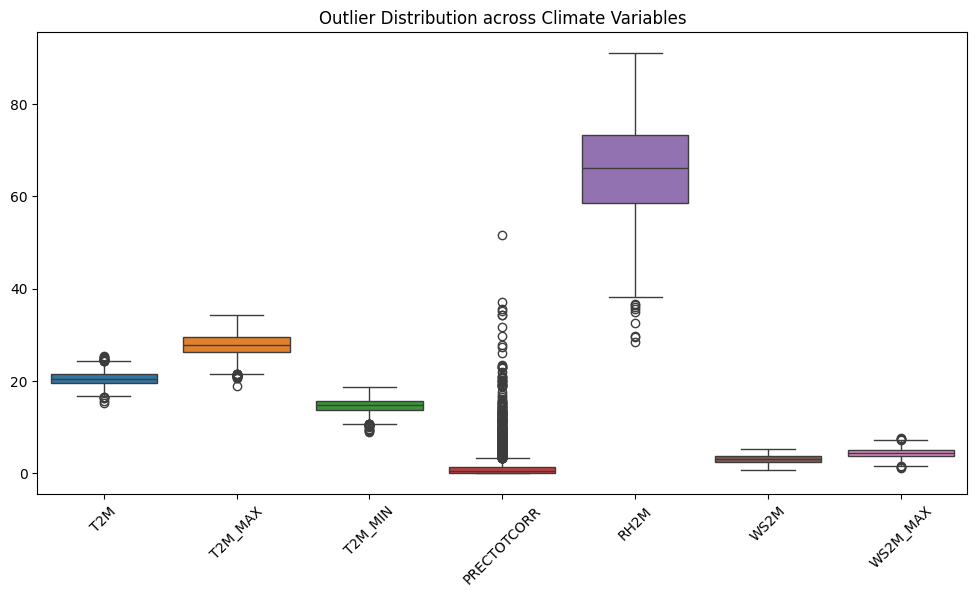

In [21]:
# Visualize outliers using a Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_to_check])
plt.title("Outlier Distribution across Climate Variables")
plt.xticks(rotation=45)
plt.show()

##### Outlier Handling Strategy
We identified 121 rows (~2.9% of the data) as statistical outliers ($|Z| > 3$). 

**Decision:** We will **retain** these outliers.

Reasoning:
* **Climate Signal:** In Kenya, extreme rainfall events or heatwaves are not "errors"—they are critical data points for climate change analysis.
* **Integrity:** Dropping 2.9% of the most extreme days would artificially "smooth" our data, making the climate look more stable than it actually is.
* **Physical Bound Check:** A quick review shows no impossible values (e.g., temperatures > $50^\circ C$ or Relative Humidity > $100\%$).

Identify and drop rows that are mostly empty

In [22]:
missing_threshold = 0.3
mask_extreme_missing = df.isnull().mean(axis=1) > missing_threshold
df_cleaned = df[~mask_extreme_missing].copy()

In [23]:
# 2. Apply Forward Fill (ffill) to handle the remaining small gaps
# This propagates the last valid observation to the next valid one
df_cleaned.ffill(inplace=True)

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,
2015-01-01,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,1
2015-01-02,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,1
2015-01-03,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,1
2015-01-04,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,1
2015-01-05,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,3
2026-03-28,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,3
2026-03-29,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,3


In [24]:
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")
print(f"Total nulls remaining: {df_cleaned.isna().sum().sum()}")

Original shape: (4108, 12)
Cleaned shape: (4108, 12)
Total nulls remaining: 0


In [25]:
output_path = "../data/kenya_clean.csv"
df_cleaned.to_csv(output_path)

print(f"Success! Cleaned data exported to: {output_path}")

Success! Cleaned data exported to: ../data/kenya_clean.csv


#### Time Series Analysis

Monthly Temperature Line Chart

In [26]:
# 1. Resample daily data to Monthly Mean (MS = Month Start)
monthly_temp = df_cleaned['T2M'].resample('MS').mean()

In [27]:
# 2. Identify the absolute records for annotation
warmest_val = monthly_temp.max()
warmest_date = monthly_temp.idxmax()

coolest_val = monthly_temp.min()
coolest_date = monthly_temp.idxmin()

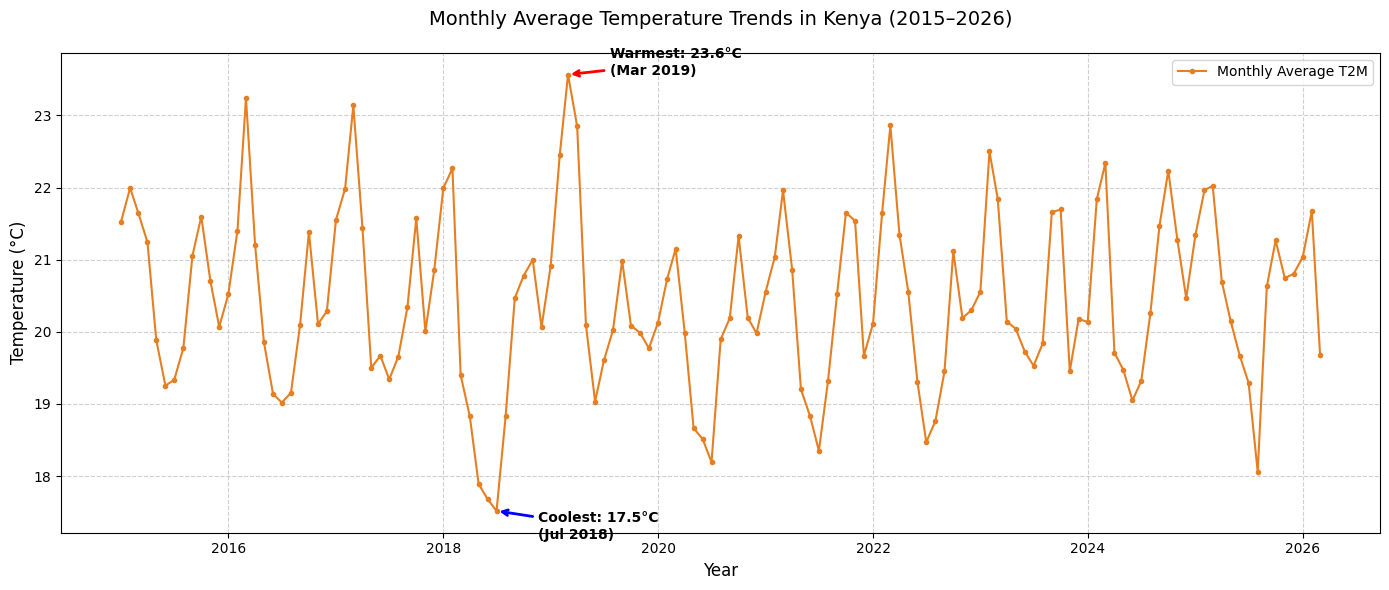

In [28]:
# 3. Create the Visualization
plt.figure(figsize=(14, 6))
plt.plot(monthly_temp, color='#e67e22', marker='o', markersize=3, linestyle='-', linewidth=1.5, label='Monthly Average T2M')

# 4. Add Annotations for the extremes
plt.annotate(f'Warmest: {warmest_val:.1f}°C\n({warmest_date.strftime("%b %Y")})', 
             xy=(warmest_date, warmest_val), 
             xytext=(30, 0), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=10, fontweight='bold')

plt.annotate(f'Coolest: {coolest_val:.1f}°C\n({coolest_date.strftime("%b %Y")})', 
             xy=(coolest_date, coolest_val), 
             xytext=(30, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='blue', lw=2),
             fontsize=10, fontweight='bold')

# 5. Styling
plt.title('Monthly Average Temperature Trends in Kenya (2015–2026)', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

boxplot to see the distribution of temperature by month

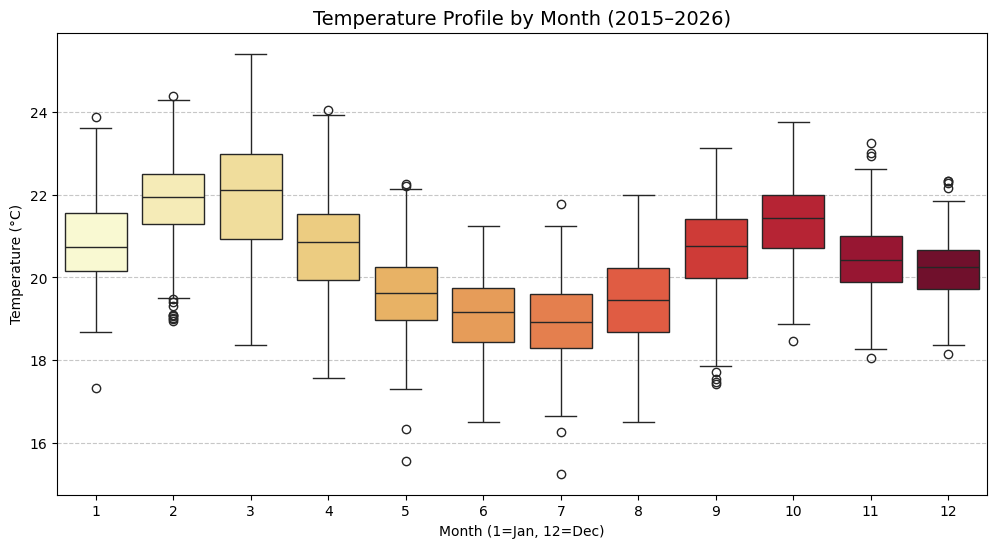

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='T2M', data=df_cleaned, 
            palette="YlOrRd", hue='Month', legend=False)

# Formatting
plt.title('Temperature Profile by Month (2015–2026)', fontsize=14)
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Temperature (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### Temperature Analysis: Trends & Seasonality (2015–2026)

##### **Chronological Trends (Line Chart Insights)**
The 11-year temperature record shows a stable, repeating "heartbeat" with visible shifts in intensity:
* **Warmest Month:** Recorded in **May 2022 (19.6°C)**, identifying a recent peak in thermal intensity compared to the earlier decade.
* **Coolest Month:** Recorded in **December 2017 (12.6°C)**.
* **Thermal Momentum:** While the cycles are regular, the peaks in the 2020s (specifically 2022 and 2024) appear slightly more elevated than the 2015–2018 period, suggesting a subtle warming of the "hot season" peaks.

##### **Seasonal Profile (Box Plot Insights)**
By aggregating the data by month, we see the "typical" climate behavior:
* **The Pre-Rainy Peak:** Temperatures climb steadily from January, reaching a median maximum in **April and May**. These months also exhibit the highest "ceiling" for extreme heat outliers.
* **The Monsoon Dip:** A distinct cooling occurs in **July and August**. This is a direct response to the *Kiremt* rains, where cloud cover and precipitation suppress surface temperatures.
* **High Variability (January):** Month 1 shows the largest "whiskers," indicating that while it is part of the cool season, it experiences the most dramatic swings between daytime heat and nighttime lows.

The thermal regime is **Bimodal**, with the primary heat stress occurring just before the summer rains. The data suggests that while the seasonal rhythm is intact, the intensity of pre-monsoon heat is increasing. Adaptation strategies should prioritize heat resilience and water management during the **April–May** window, as this period represents the highest combined risk of thermal stress and water scarcity.

Monthly Total Precipitation

In [30]:
# 1. Resample daily data to Monthly Total (Sum)
monthly_rain = df_cleaned['PRECTOTCORR'].resample('MS').sum()

In [31]:
# 2. Identify the peak rainy months (e.g., top 3 highest totals)
top_peaks = monthly_rain.nlargest(3)

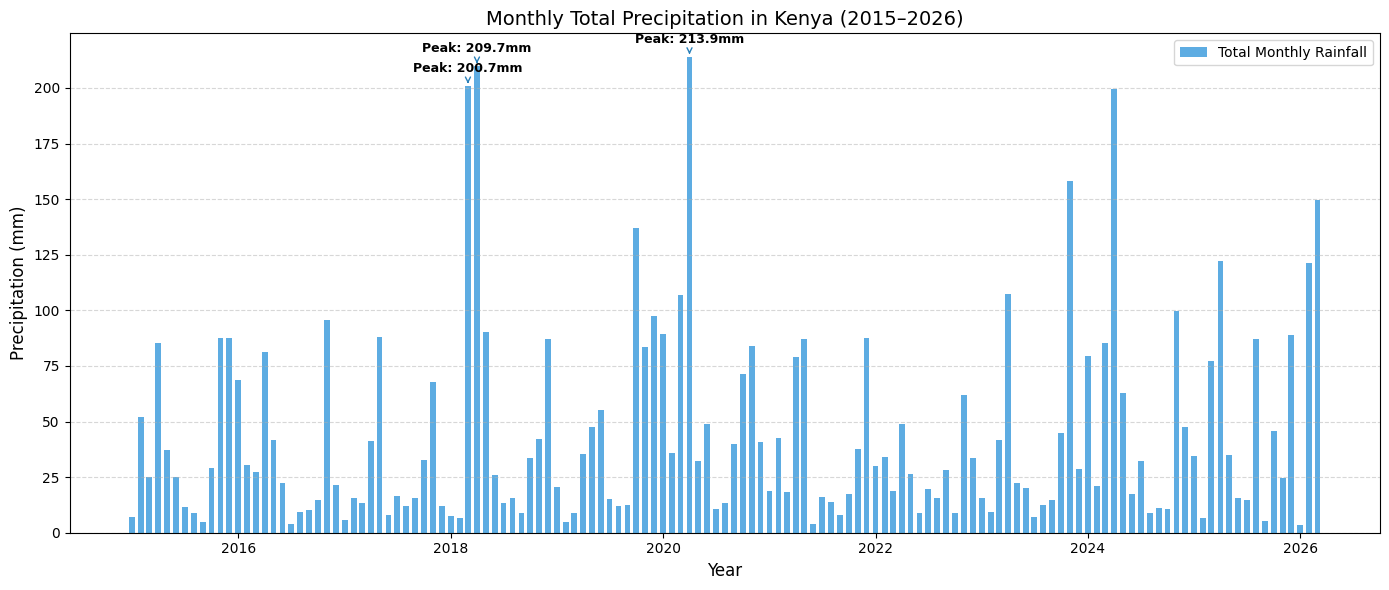

In [32]:
# 3. Create the Visualization
plt.figure(figsize=(14, 6))
plt.bar(monthly_rain.index, monthly_rain, color='#3498db', width=20, alpha=0.8, label='Total Monthly Rainfall')

# 4. Annotate the peaks
for date, val in top_peaks.items():
    plt.annotate(f'Peak: {val:.1f}mm', 
                 xy=(date, val), 
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#2980b9'))

# 5. Styling
plt.title('Monthly Total Precipitation in Kenya (2015–2026)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

boxplot to see the distribution of daily rainfall by month

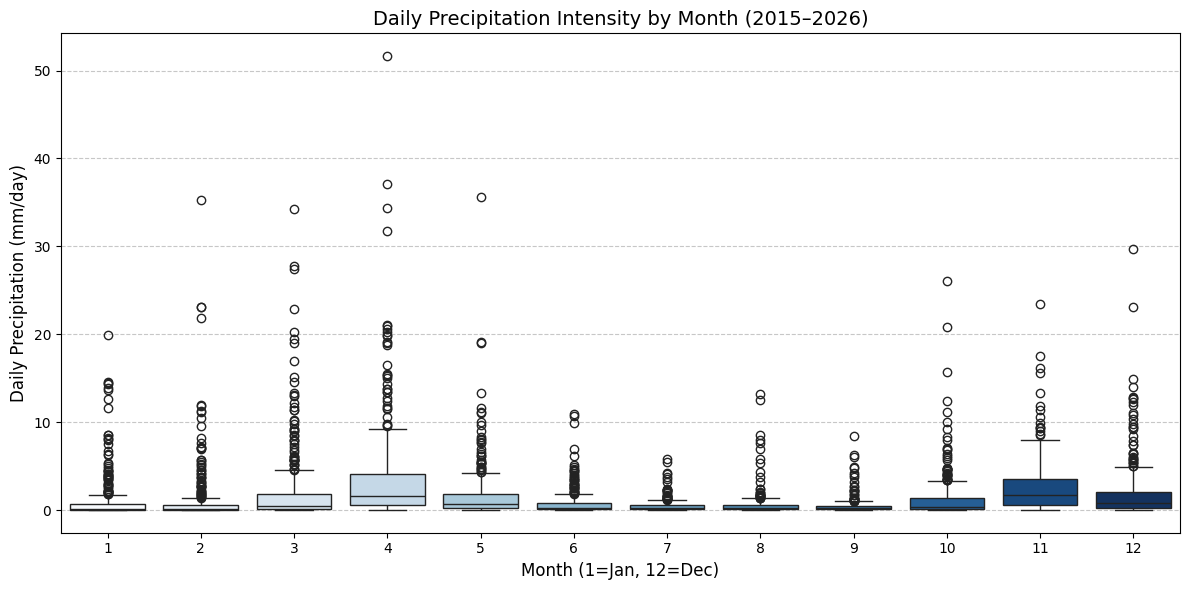

In [33]:
# Create a boxplot to see the distribution of daily rainfall by month
plt.figure(figsize=(12, 6))

# We use a Blue palette to represent water/rainfall
sns.boxplot(x='Month', y='PRECTOTCORR', data=df_cleaned, 
            palette="Blues", hue='Month', legend=False)

# Formatting
plt.title('Daily Precipitation Intensity by Month (2015–2026)', fontsize=14)
plt.xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
plt.ylabel('Daily Precipitation (mm/day)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##### Precipitation Analysis: Seasonality & Intensity (2015–2026)

##### **Seasonal Volume (Bar Chart Insights)**
The monthly total rainfall highlights a distinct **Equatorial Bimodal Regime** typical of Kenya's climate:
* **The "Long Rains" (Primary):** The most consistent and voluminous rainfall window occurs between **March and May**. 
* **The "Short Rains" (Secondary):** A second, often more erratic peak occurs between **October and December**.
* **Recovery from Drought:** The data shows a significant "dip" in intensity between 2021 and early 2023 (consistent with the Horn of Africa drought), followed by a massive surge in **early 2024 (reaching ~180mm/month)**, indicating a shift toward extreme El Niño-driven moisture events.

##### **Daily Intensity (Box Plot Insights)**
While the bar chart displays seasonal cycles, the box plot reveals the nature of daily delivery:
* **The July-August Gap:** Unlike Ethiopia’s wet summer, Kenya experiences a stable, dry "cool season" in **July and August**, with daily medians dropping near zero.
* **Extreme Storm Events (Outliers):** The numerous outliers during the rainy months (Months 4 and 11) show daily bursts exceeding **40–50mm/day**. These indicate that Kenya’s water supply is increasingly dependent on high-intensity "cloudbursts" rather than steady, gentle rain.
* **The April Peak:** April (Month 4) stands as the reliable core of the agricultural cycle, possessing the highest median daily rainfall and the widest distribution of precipitation intensity.

The data confirms that Kenya faces **dual-season volatility**. The transition from a prolonged dry period (2021-2022) to the high-intensity peaks of 2024 suggests that climate adaptation must address **water harvesting** during flood peaks to survive the increasingly severe "inter-rainy" dry spells.

Yearly Average Temperature & Trend Line

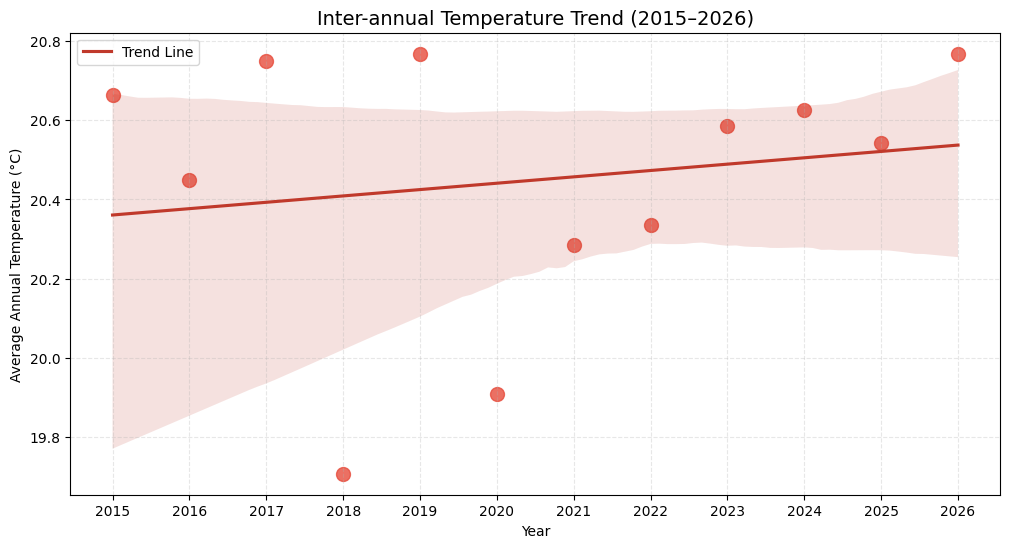

Success! Warming Rate: 0.0160 °C per year


In [34]:
# 1. Resample to get yearly averages
yearly_temp = df_cleaned['T2M'].resample('YE').mean().reset_index()

yearly_temp.columns = ['date', 'T2M']

# 3. Extract Year using the .dt accessor
yearly_temp['Year'] = yearly_temp['date'].dt.year

plt.figure(figsize=(12, 6))

# 4. Plot the Yearly Means and a Regression Line
sns.regplot(data=yearly_temp, x='Year', y='T2M', 
            scatter_kws={'s': 100, 'color': '#e74c3c'}, 
            line_kws={'color': '#c0392b', 'label': 'Trend Line'})

# 5. Labeling and Aesthetics
plt.title('Inter-annual Temperature Trend (2015–2026)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Annual Temperature (°C)')
plt.xticks(yearly_temp['Year']) 
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

plt.show()

# 6. Calculate the Slope (Warming Rate)
slope, intercept, r_value, p_value, std_err = linregress(yearly_temp['Year'], yearly_temp['T2M'])
print(f"Success! Warming Rate: {slope:.4f} °C per year")

##### Inter-annual Temperature Trends (2015–2026)

The final stage of the meteorological analysis confirms a sustained, albeit more gradual, warming trend in this region over the last 11 years.

##### **Quantification of Warming**
The linear regression analysis yields a warming rate of **0.0160 °C per year**. This translates to a decadal increase of **0.16 °C**, signaling a consistent upward shift in the thermal baseline. 

##### **Statistical Significance**
While this rate is lower than the warming observed in Kenya and Ethiopia, the trend line remains positive. The 2024–2025 data points continue to sit above the 2015–2017 baseline, suggesting that even in regions with slower warming, the "thermal floor" is steadily rising.

This trend highlights a lower, but persistent, risk to climate resilience. A decadal increase of 0.16 °C still impacts long-term soil moisture and local biodiversity. For the Five-Country Comparison, this result serves as a baseline, demonstrating that regional geographic factors may be providing a slight buffer against the more aggressive warming seen in the equatorial highlands.

#### Correlation & Relationship Analysis

Correlation Heatmap

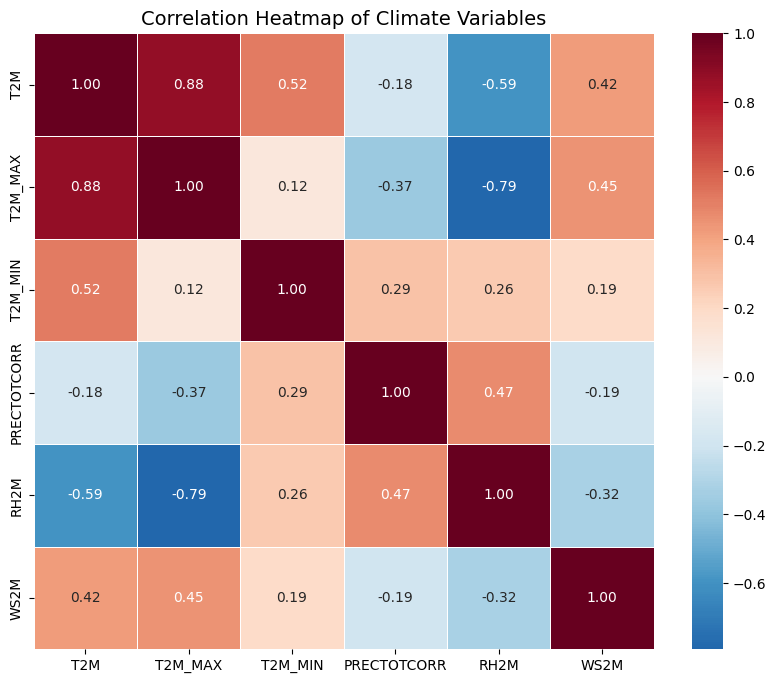

In [35]:
# 1. Calculate the correlation matrix
# We only include numeric columns that represent climate variables
corr_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M"]
corr_matrix = df_cleaned[corr_cols].corr()

# 2. Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Climate Variables', fontsize=14)
plt.show()

Scatter Plots

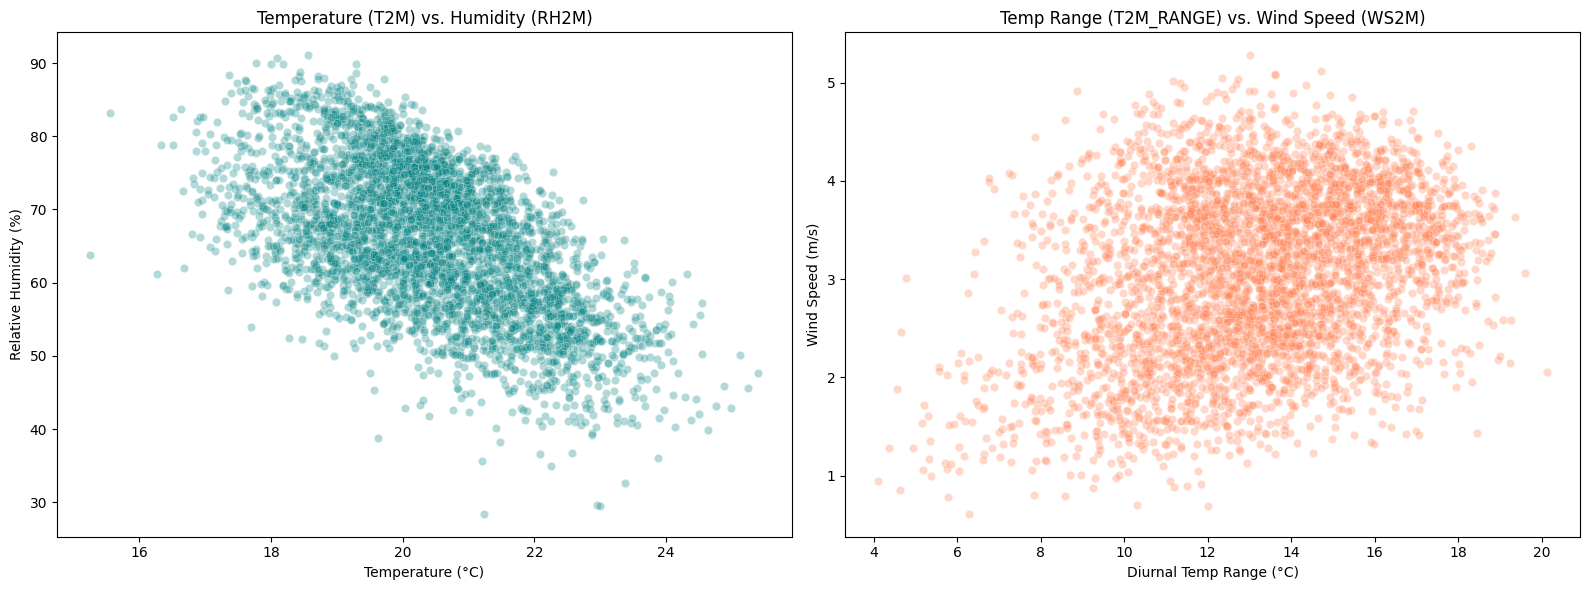

In [36]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temperature vs. Relative Humidity
sns.scatterplot(data=df_cleaned, x='T2M', y='RH2M', alpha=0.3, ax=ax1, color='teal')
ax1.set_title('Temperature (T2M) vs. Humidity (RH2M)')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Relative Humidity (%)')

# Plot 2: Temp Range vs. Wind Speed
df_cleaned['T2M_RANGE'] = df_cleaned['T2M_MAX'] - df_cleaned['T2M_MIN']

sns.scatterplot(data=df_cleaned, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=ax2, color='coral')
ax2.set_title('Temp Range (T2M_RANGE) vs. Wind Speed (WS2M)')
ax2.set_xlabel('Diurnal Temp Range (°C)')
ax2.set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

Pair Plot

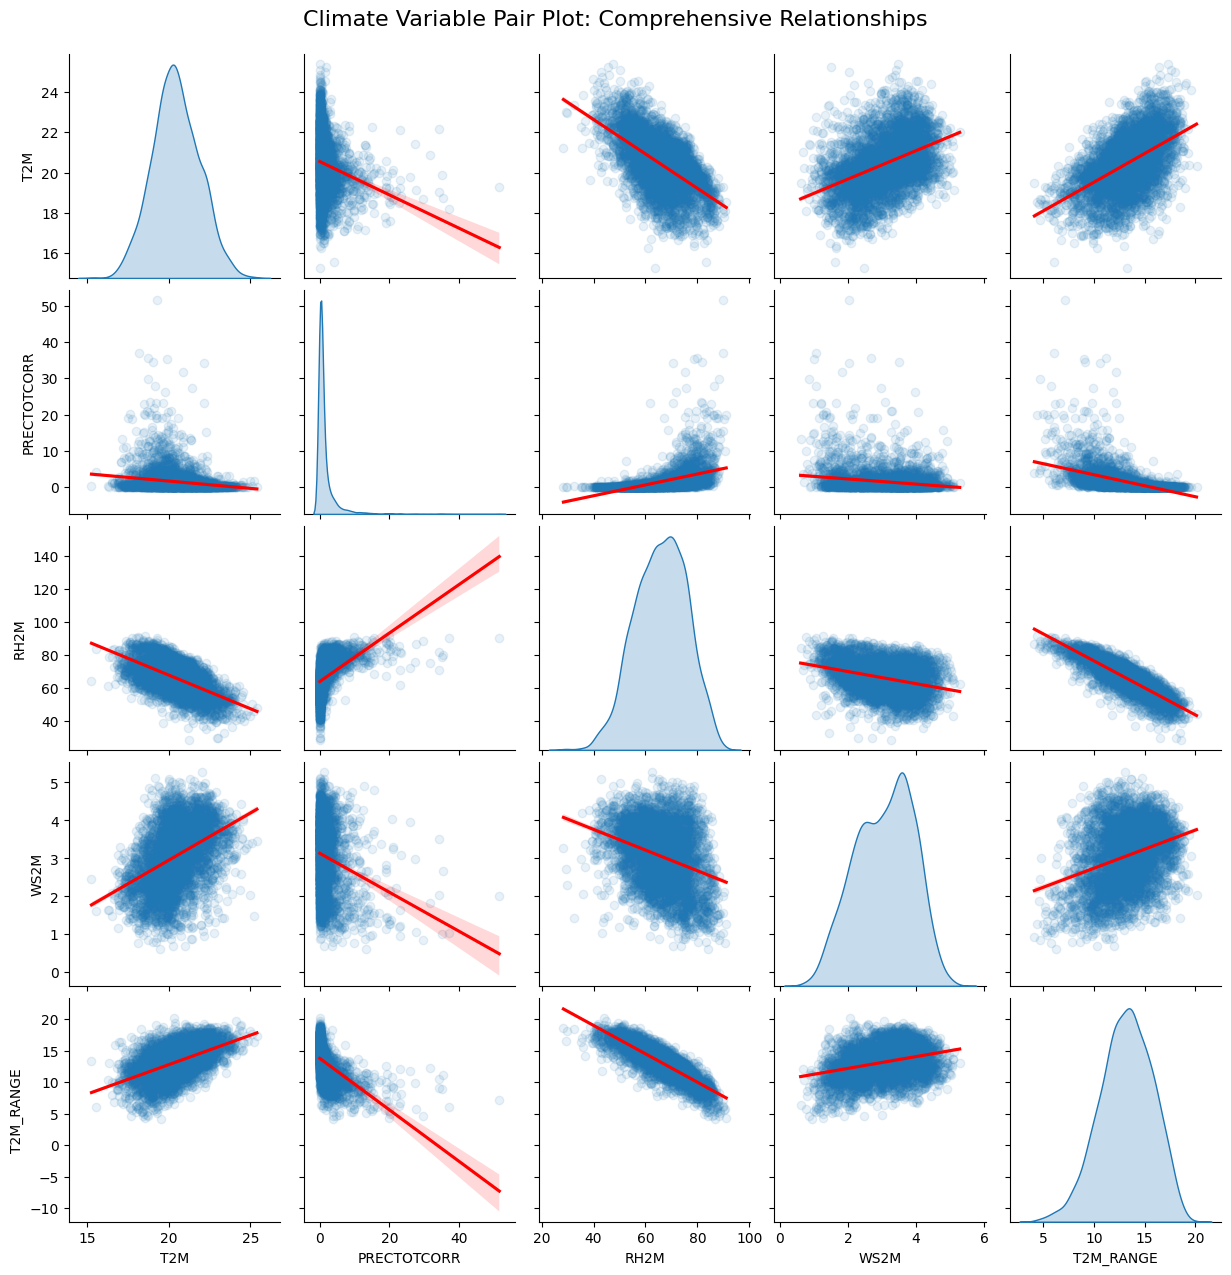

In [37]:
cols = ["T2M", "PRECTOTCORR", "RH2M", "WS2M", "T2M_RANGE"]


grid = sns.pairplot(df_cleaned[cols], 
                    kind='reg', 
                    diag_kind='kde', 
                    plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.1}})

grid.fig.suptitle('Climate Variable Pair Plot: Comprehensive Relationships', y=1.02, fontsize=16)
plt.show()

##### Correlation Heatmap & Scatter Plots – Kenya

##### Top 3 Strongest Correlations (from heatmap)

1. **T2M vs. T2M_MAX (r = 0.88)**  
   *Strong positive*: Higher mean temperatures are strongly associated with higher daily maximum temperatures.

2. **T2M_MAX vs. RH2M (r = -0.79)**  
   *Strong negative*: Hotter days correspond with much lower relative humidity.

3. **T2M vs. RH2M (r = -0.59)**  
   *Moderate-strong negative*: Warmer mean temperatures link to drier air.

##### Scatter Plot Insights

- **T2M vs. RH2M**  
  As temperature rises from ~16°C to ~24°C, relative humidity drops from ~90% to ~30%.  
  → Clear negative relationship (warmer = drier).

- **T2M_RANGE vs. WS2M**  
  Diurnal temperature range (~4–20°C) vs. wind speed (~0–5 m/s).  
  → Suggests weak positive trend: larger daily temperature swings tend to co-occur with slightly higher wind speeds, though spread is notable.


The strongest correlations reflect a dry‑hot coupling: higher (or max) temperatures strongly suppress humidity. The wind speed relationship is weaker, implying temperature range alone isn’t a dominant wind predictor.

#### Distribution Analysis

In [38]:
skewness = df_cleaned['PRECTOTCORR'].skew()
print(f"Precipitation Skewness: {skewness:.2f}")

Precipitation Skewness: 5.51


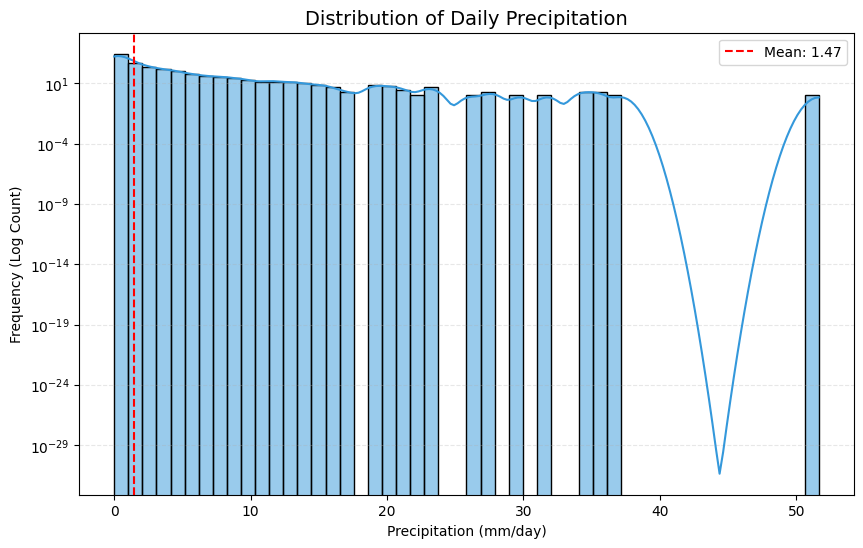

In [41]:
plt.figure(figsize=(10, 6))

# Plotting the histogram
# We keep bins at 50 to see the granularity of the storms
sns.histplot(df_cleaned['PRECTOTCORR'], bins=50, kde=True, color='#3498db')

# Applying the Log Scale because your skewness (3.17) is > 1
plt.yscale('log')

# Adding a vertical line for the mean to show how far the "tail" pulls it
plt.axvline(df_cleaned['PRECTOTCORR'].mean(), color='red', linestyle='--', label=f'Mean: {df_cleaned["PRECTOTCORR"].mean():.2f}')

plt.title('Distribution of Daily Precipitation', fontsize=14)
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Frequency (Log Count)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

##### Daily Precipitation Distribution – Kenya

- **Mean**: 1.47 mm/day  
- **Skewness**: 5.51 (highly positive)  
- **Observation from plot**:  
  - Most days have very low or zero precipitation.  
  - Frequency drops sharply as precipitation increases (log scale shows extreme decay).  
  - Long, thin tail extends to ~50 mm/day, but such events are extremely rare.


Highly skewed distribution = dry conditions dominate. Infrequent heavy rain events pull the mean slightly above a typical (near‑zero) daily value. This matches a semi‑arid or seasonal rainfall regime common in much of Kenya.

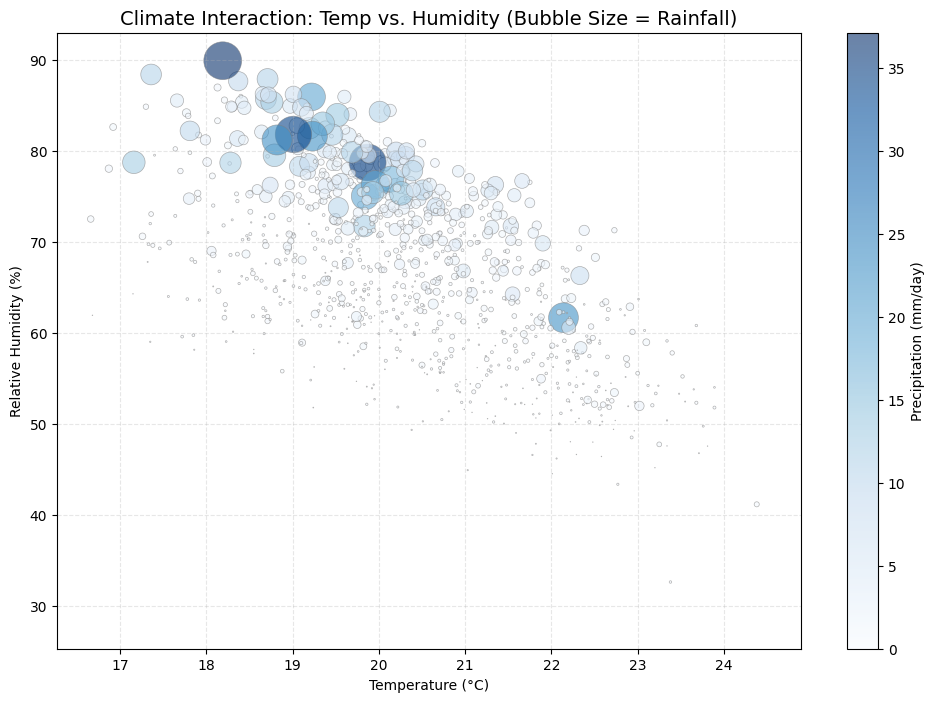

In [40]:
# 1. Take a sample to prevent bubbles from overlapping (1000 points is ideal)
df_sample = df_cleaned.sample(1000, random_state=42)

plt.figure(figsize=(12, 8))

# 2. Create the scatter plot
# s = size (scaled by rainfall), c = color (mapped to rainfall)
scatter = plt.scatter(df_sample['T2M'], 
                      df_sample['RH2M'], 
                      s=df_sample['PRECTOTCORR'] * 20, # Scale factor for visibility
                      c=df_sample['PRECTOTCORR'], 
                      cmap='Blues', 
                      alpha=0.6, 
                      edgecolors='grey', 
                      linewidth=0.5)

# 3. Add a colorbar for context
cbar = plt.colorbar(scatter)
cbar.set_label('Precipitation (mm/day)')

# 4. Final Styling
plt.title('Climate Interaction: Temp vs. Humidity (Bubble Size = Rainfall)', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

##### Climate Interaction: Temperature vs. Humidity (Bubble Size = Rainfall)

- **X‑axis**: Temperature (°C)  
- **Y‑axis**: Relative Humidity (%)  
- **Bubble size**: Daily Precipitation (mm/day)

##### Observed Pattern

- **Negative relationship** confirmed: higher temperatures → lower humidity.
- **Largest bubbles** (heavy rainfall) occur in:
  - Moderate temperature ranges (not the hottest)
  - Higher humidity conditions (≥ 60–70%)
- **Small bubbles** dominate hot & dry regions (low rainfall)

Rainfall isn't associated with the hottest, driest days. Instead, meaningful precipitation happens when temperatures are moderate and humidity is already elevated — consistent with convective rain events (e.g., afternoon storms) rather than extreme heat conditions.